<a href="https://colab.research.google.com/github/Muthumeena06/SPAM-EMIAL-DETECTION-USINGML/blob/main/AIML_CT_PROJECT_2_MUTHUMEENA_CSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SPAM** **EMAIL** **DETECTION**


**WORKFLOW**

Dataset
   ↓
Data Preprocessing
   ↓
TF-IDF Feature Extraction
   ↓
Train-Test Split
   ↓
Multinomial Naive Bayes Model
   ↓
Model Evaluation
   ↓
Save Model
   ↓
New Email Input
   ↓
Spam / Not Spam Prediction

**IMPORT** **LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

**UPLOAD** **DATASET**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving SPAM EMAIL.zip to SPAM EMAIL.zip


In [3]:
import zipfile
import os

zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.')

if os.path.exists('spam.csv'):
    print("'spam.csv' has been extracted successfully.")
else:
    print("Error: 'spam.csv' not found after extraction.")

'spam.csv' has been extracted successfully.


**LOAD** **DATASET**

In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")

**KEEP** **REQUIRED** **COLUMN**

In [5]:
df = df[['v1','v2']]
df.columns = ['label','message']

**DISPLAY** **DATASET**

In [6]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


**HEAD**

In [7]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**TAIL**

In [8]:
df.tail()

,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


**SHAPE**

In [9]:
df.shape

(5572, 2)

**COLUMNS**

In [10]:
df.columns

Index(['label', 'message'], dtype='object')

**DATA** **TYPES**

In [11]:
df.dtypes

,0
label,object
message,object


**INFO**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


**DESCRIBE**

In [13]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


**CHECK** **MISSING** **VALUES**

In [14]:
df.isnull().sum()

,0
label,0
message,0


**CHECK** **DUPLICATES**

In [15]:
df.duplicated().sum()

np.int64(403)

**REMOVE** **DUPLICATES**

In [16]:
df = df.drop_duplicates()
df.shape

(5169, 2)

**CHECK** **UNIQUE** **VALUES**

In [17]:
df.nunique()

,0
label,2
message,5169


**TARGET** **VARIABLE** **DISTRIBUTION**

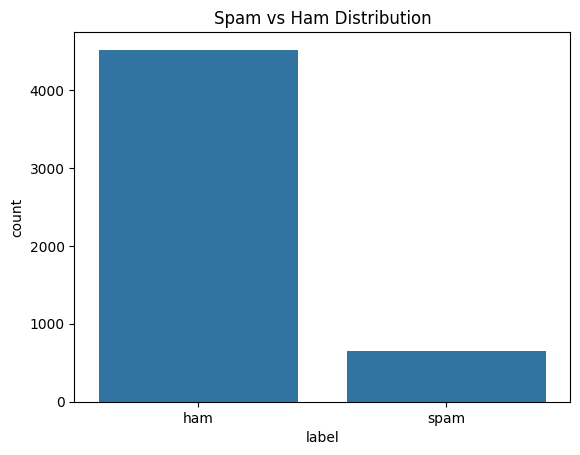

In [18]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

**CORRELATION** **MATRIX**

In [19]:
df['label_num'] = df['label'].map({'ham':0,'spam':1})

df['length'] = df['message'].apply(len)

corr = df[['label_num','length']].corr()

corr

/tmp/ipykernel_674/4121525558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label_num'] = df['label'].map({'ham':0,'spam':1})
/tmp/ipykernel_674/4121525558.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['length'] = df['message'].apply(len)


,label_num,length
label_num,1.000000,0.384717
length,0.384717,1.000000


**HEAT** **MAP**

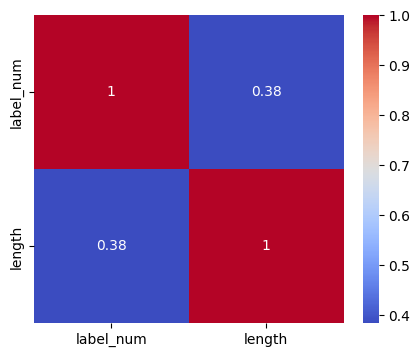

In [20]:
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**HISTOGRAM**

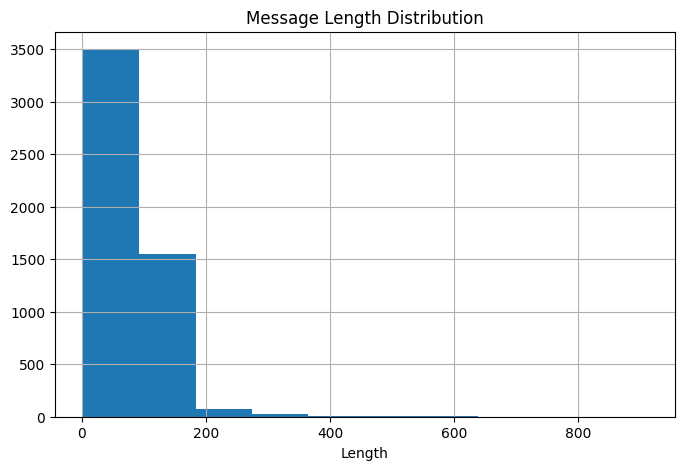

In [21]:
df['length'].hist(figsize=(8,5))
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.show()

**COUNT** **PLOT**

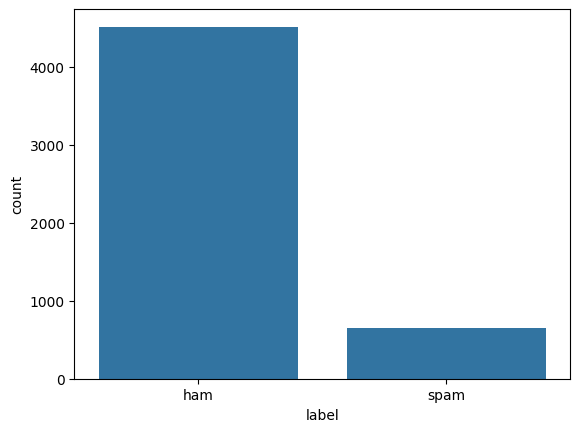

In [22]:
sns.countplot(x='label', data=df)
plt.show()

**BOX** **PLOT**

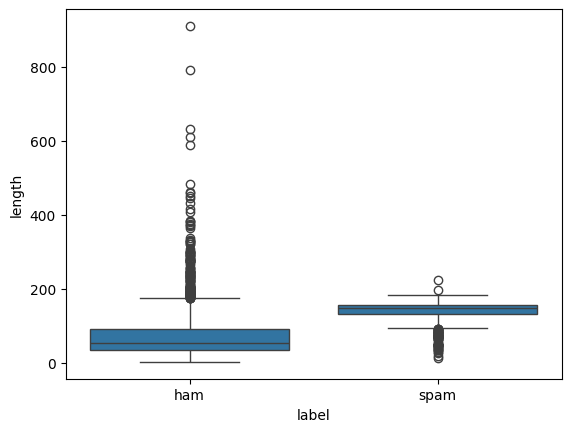

In [23]:
sns.boxplot(x='label', y='length', data=df)
plt.show()

**SCATTER** **PLOT**

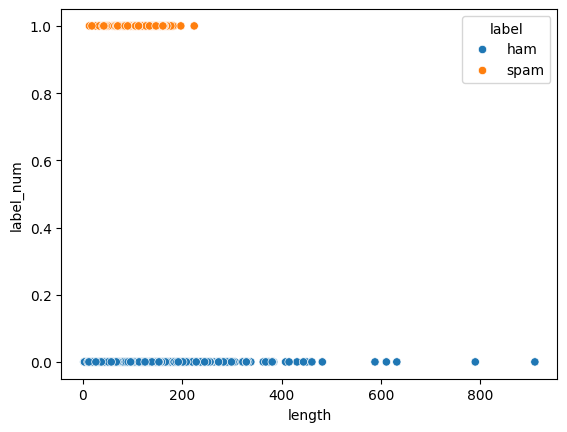

In [24]:
sns.scatterplot(x='length', y='label_num', hue='label', data=df)
plt.show()

**PAIR** **PLOT**

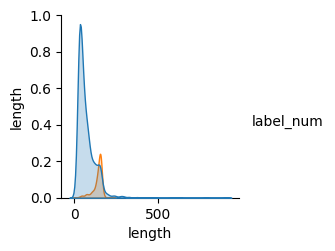

In [25]:
sns.pairplot(df[['length','label_num']], hue='label_num')
plt.show()

**KDE** **PLOT**

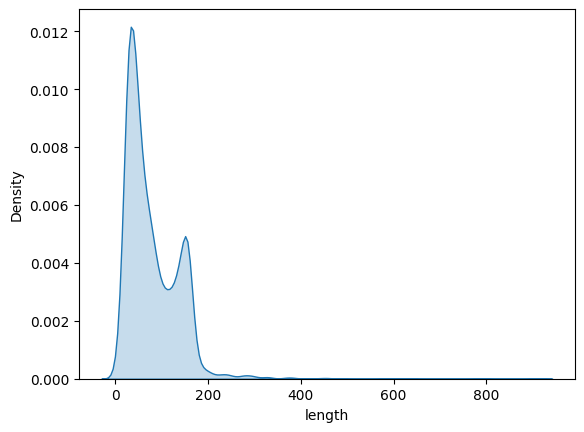

In [26]:
sns.kdeplot(data=df, x='length', fill=True)
plt.show()

VIOLIN PLOT

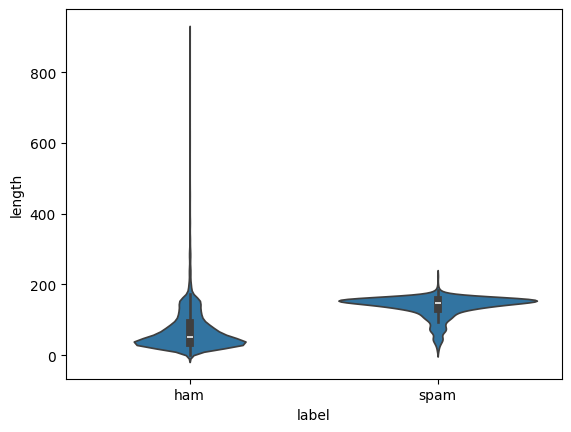

In [27]:
sns.violinplot(x='label', y='length', data=df)
plt.show()

BAR PLOT

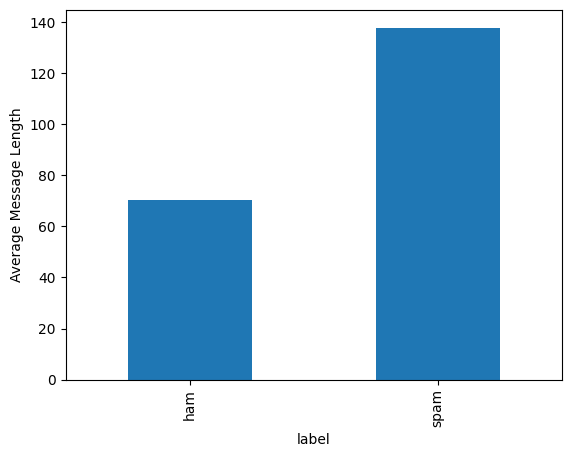

In [28]:
df.groupby('label')['length'].mean().plot(kind='bar')
plt.ylabel("Average Message Length")
plt.show()

PIE CHART

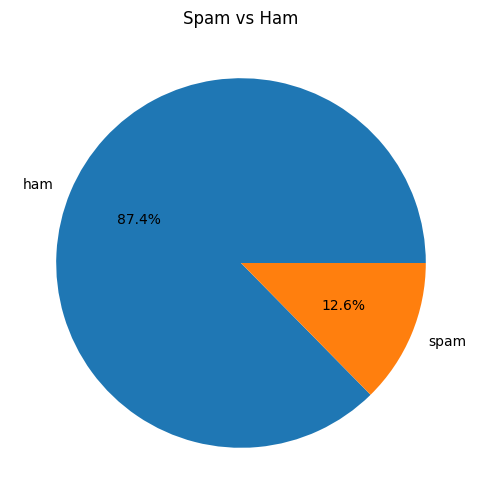

In [29]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Spam vs Ham")
plt.ylabel("")
plt.show()

DETECT OUTLIERS UDING IQR

In [30]:
df['length'] = df['message'].apply(len)

Q1 = df['length'].quantile(0.25)
Q3 = df['length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['length'] < lower) | (df['length'] > upper)]

print("Number of Outliers:", outliers.shape[0])

df = df[(df['length'] >= lower) & (df['length'] <= upper)]

print("Dataset Shape after Removing Outliers:", df.shape)

Number of Outliers: 66
Dataset Shape after Removing Outliers: (5103, 4)


/tmp/ipykernel_674/1326067719.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['length'] = df['message'].apply(len)


FEATURE ENGINEERING

In [31]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

df['char_count'] = df['message'].apply(len)

df.head()

,label,message,label_num,length,word_count,char_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,111
1,ham,Ok lar... Joking wif u oni...,0,29,6,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,155
3,ham,U dun say so early hor... U c already then say...,0,49,11,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,61


FEAURE SELECTION

In [32]:
X = df['message']
y = df['label']

ENCODING CATEGORICAL DATA

In [33]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])


y = df['label']

FEATURE SCALLING

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['message'])

SPLIT DATASET

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4082, 8080)
(1021, 8080)


CHOOSE ALGORITHM

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

LOGISTIC REGRESSION

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy*100)

Logistic Regression Accuracy: 94.80901077375123


NAIVE BAYES

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Accuracy:", accuracy*100)

Naive Bayes Accuracy: 97.35553379040157


DECISION TREE

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy*100)

Decision Tree Accuracy: 96.66993143976494


RANDOM FOREST

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy*100)

Random Forest Accuracy: 97.64936336924583


SUPPORT VECTOR MACHINE

In [41]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy*100)

SVM Accuracy: 97.64936336924583


COMPARE ALL ALGORITHM

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": LinearSVC(random_state=42)
}

results = []

print("----------- MODEL ACCURACY -----------\n")

for name, model in models.items():


    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred) * 100

    print(f"{name} : {accuracy:.2f}%")

    results.append([name, accuracy])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"])

print("\n----------- ACCURACY TABLE -----------")
print(results_df)

best_model = results_df.loc[results_df["Accuracy (%)"].idxmax()]

print("\n======================================")
print("Best Model :", best_model["Model"])
print("Best Accuracy :", round(best_model["Accuracy (%)"], 2), "%")
print("======================================")

----------- MODEL ACCURACY -----------

Logistic Regression : 94.81%
Naive Bayes : 97.36%
Decision Tree : 96.67%
Random Forest : 97.65%
Support Vector Machine : 97.65%

----------- ACCURACY TABLE -----------
                    Model  Accuracy (%)
0     Logistic Regression     94.809011
1             Naive Bayes     97.355534
2           Decision Tree     96.669931
3           Random Forest     97.649363
4  Support Vector Machine     97.649363

Best Model : Random Forest
Best Accuracy : 97.65 %


TRAIN THE FINAL SVM MODEL

In [43]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

EVALUATE THE SVM MODEL

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 97.64936336924583

Confusion Matrix
[[899   2]
 [ 22  98]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       901
           1       0.98      0.82      0.89       120

    accuracy                           0.98      1021
   macro avg       0.98      0.91      0.94      1021
weighted avg       0.98      0.98      0.98      1021



SAVE THE BEST MODEL

In [45]:
import pickle

pickle.dump(svm_model, open("svm_spam_model.pkl", "wb"))

pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


LOAD THE SAVED MODEL

In [46]:
import pickle

loaded_model = pickle.load(open("svm_spam_model.pkl", "rb"))
loaded_vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

print("Model Loaded Successfully!")

Model Loaded Successfully!


TEST THE MODEL ON NEW EMAILS

In [51]:
new_email = ["Congratulations! You have won a free iPhone. Click here to claim your prize."]

new_email_vector = loaded_vectorizer.transform(new_email)

prediction = loaded_model.predict(new_email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Ham Email")

Spam Email


In [49]:
from google.colab import files
files.download('svm_spam_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**CONCLUSION**



This project successfully developed a **Spam Email Detection System** using Machine Learning to classify emails as **Spam** or **Ham**. By comparing different algorithms, **Support Vector Machine (SVM)** provided the best performance and accuracy. The system helps improve email security by filtering unwanted messages and can be further enhanced for real-world applications.
